# 01 — Differentiation, Gradients & Jacobians

**Book reference:** *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong) — §5.1–5.4, pp.141–157 (Differentiation of Univariate Functions, Partial Differentiation and Gradients, Gradients of Vector-Valued Functions, Gradients of Matrices)

Part of the Calculus subchapter of the 6-month ML Engineer prep plan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## The derivative is just a slope

`f'(x)` is the slope of the tangent line to `f` at `x` — the limit of the slope of a secant line as the two points it connects get infinitely close:

```
f'(x) = lim_{h->0} [f(x+h) - f(x)] / h
```

Everything else in this chapter — gradients, Jacobians, backprop — is this same idea, generalized to more inputs and outputs.

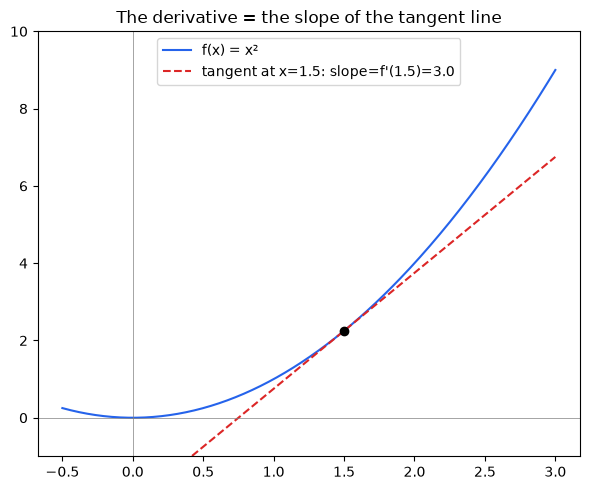

In [2]:
def visualize_tangent_line(f, fprime, x0, savepath: Path = None, xlim=(-0.5, 3)):
    x = np.linspace(*xlim, 300)
    y = f(x)
    slope = fprime(x0)
    tangent_y = f(x0) + slope * (x - x0)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(x, y, color="#2563eb", label="f(x) = x²")
    ax.plot(x, tangent_y, color="#dc2626", linestyle="--",
            label=f"tangent at x={x0}: slope=f'({x0})={slope:.1f}")
    ax.scatter([x0], [f(x0)], color="black", zorder=5)
    ax.set_ylim(-1, f(xlim[1]) + 1)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.legend()
    ax.set_title("The derivative = the slope of the tangent line")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_tangent_line(lambda x: x**2, lambda x: 2*x, 1.5, FIG_DIR / "tangent_line.png")

## Partial derivatives and the gradient

For a function of several variables, `f(x, y)`, the **partial derivative** `∂f/∂x` treats `y` as fixed and differentiates with respect to `x` alone. Stack all the partial derivatives into a vector and you get the **gradient**:

```
∇f = [∂f/∂x1, ∂f/∂x2, ..., ∂f/∂xn]
```

The gradient has a crucial geometric property: **it always points in the direction of steepest ascent, and it's always perpendicular to the contour lines of `f`.** That single fact is the entire justification for gradient *descent* — step in the direction opposite the gradient to decrease the function fastest.

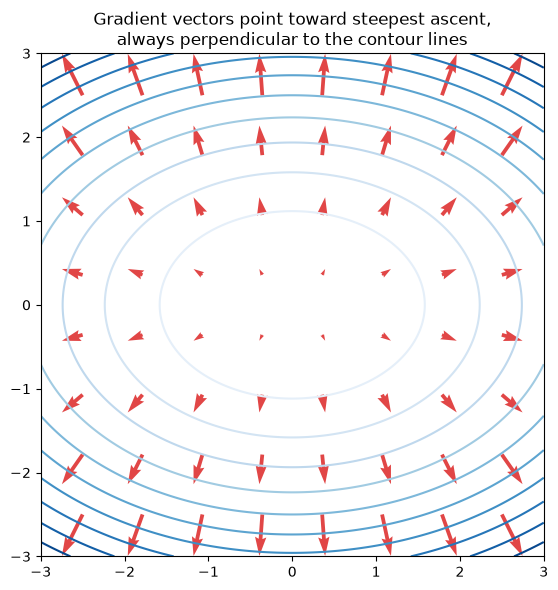

In [3]:
def visualize_gradient_field(savepath: Path = None):
    xc = np.linspace(-3, 3, 200)
    yc = np.linspace(-3, 3, 200)
    Xc, Yc = np.meshgrid(xc, yc)
    Zc = Xc**2 + 2*Yc**2   # f(x, y) = x^2 + 2y^2

    xs = np.linspace(-2.5, 2.5, 8)
    ys = np.linspace(-2.5, 2.5, 8)
    Xs, Ys = np.meshgrid(xs, ys)
    dZdx = 2 * Xs          # partial derivative w.r.t. x
    dZdy = 4 * Ys          # partial derivative w.r.t. y

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.contour(Xc, Yc, Zc, levels=12, cmap="Blues")
    ax.quiver(Xs, Ys, dZdx, dZdy, color="#dc2626", alpha=0.85)
    ax.set_title("Gradient vectors point toward steepest ascent,\nalways perpendicular to the contour lines")
    ax.set_aspect("equal")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_gradient_field(FIG_DIR / "gradient_field.png")

Every red arrow points "uphill," away from the center (the minimum), and every arrow crosses its local contour line at a right angle. Gradient descent just walks backward along these arrows.

## The gradient of MSE loss, worked by hand

For linear regression, `L(w) = (1/n)‖Xw - y‖²`. Using the chain rule (more on this in the next notebook):

```
∂L/∂w = (2/n) · Xᵀ(Xw - y)
```

Let's verify this analytic gradient against a numerical gradient (finite differences) — this "gradient check" technique is exactly what you'd do to sanity-check a backprop implementation.

In [4]:
def mse_loss_and_grad(X, y, w):
    n = X.shape[0]
    residual = X @ w - y
    loss = np.mean(residual ** 2)
    grad = (2.0 / n) * (X.T @ residual)
    return loss, grad

def numerical_gradient(f, w, eps=1e-5):
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w_plus, w_minus = w.copy(), w.copy()
        w_plus[i] += eps
        w_minus[i] -= eps
        grad[i] = (f(w_plus) - f(w_minus)) / (2 * eps)
    return grad

rng = np.random.default_rng(0)
X = rng.normal(size=(50, 4))
true_w = rng.normal(size=4)
y = X @ true_w + rng.normal(scale=0.1, size=50)
w0 = rng.normal(size=4)

analytic_loss, analytic_grad = mse_loss_and_grad(X, y, w0)
numeric_grad = numerical_gradient(lambda w: mse_loss_and_grad(X, y, w)[0], w0)

print("Analytic gradient:", analytic_grad)
print("Numeric gradient: ", numeric_grad)
print("Max difference:   ", np.max(np.abs(analytic_grad - numeric_grad)))

Analytic gradient: [ 2.95200602  1.92539319  1.81244766 -0.94143049]
Numeric gradient:  [ 2.95200602  1.92539319  1.81244766 -0.94143049]
Max difference:    3.032252227086474e-11


The two essentially match — that's the confirmation the hand-derived gradient is correct.

## Jacobians: the gradient's generalization to vector-valued functions

A **gradient** is defined for a scalar-valued function (one output). A **Jacobian** generalizes this to a *vector*-valued function `f: Rⁿ → Rᵐ` — it's the `m × n` matrix of all partial derivatives, one row per output, one column per input:

```
J[i, j] = ∂f_i / ∂x_j
```

A gradient is just a Jacobian with a single row (`m = 1`). This distinction matters because every layer of a neural network is a vector-valued function (many inputs, many outputs), so backpropagation is really chaining Jacobians together, not just chaining scalar derivatives — that's the subject of the next notebook.

## Self-check before moving on

- [ ] I can state the definition of a derivative as a limit, and explain it as "slope of the tangent line"
- [ ] I can explain why the gradient points in the direction of steepest ascent, and why it's perpendicular to contour lines
- [ ] I can derive the gradient of MSE loss w.r.t. the weights, from scratch
- [ ] I can explain the difference between a gradient and a Jacobian
- [ ] I know what a numerical gradient check is and why it's used

Next: `02-chain-rule-backprop-autodiff.ipynb` ⭐